# Exploratory Data Analysis - E-commerce Sales & Customer Behaviour

This notebook is the *narrative* companion to the scripted pipeline in `src/`. It walks
through the same steps a working analyst would take on a new dataset:

1. Look at the raw extract and catalogue what is wrong with it.
2. Clean it, deciding (and justifying) a strategy per column.
3. Engineer the features the business questions actually need.
4. Explore: trend, seasonality, product concentration, category economics, retention, RFM.
5. Test the interesting differences formally instead of eyeballing them.

Everything here imports the **same modules** the production run uses
(`src/cleaning.py`, `src/features.py`, `src/analysis.py`), so nothing can drift between the
notebook and `reports/findings.md`.

> The dataset is **synthetic**, generated by `data/generate_dataset.py` with a fixed seed.
> It contains no real customer data.

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import analysis
import cleaning
import config
import features
import plot_style as ps

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
ps.apply_style()
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)
pd.options.display.float_format = "{:,.2f}".format

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


## 1. The raw extract

Three CSVs land in `data/raw/`. We read **everything as text** on purpose: the moment
pandas guesses a dtype it silently hides the mess we are trying to find.

In [2]:
raw_orders, raw_customers, raw_products = cleaning.load_raw()

print(f"orders    : {len(raw_orders):,} rows x {raw_orders.shape[1]} cols")
print(f"customers : {len(raw_customers):,} rows x {raw_customers.shape[1]} cols")
print(f"products  : {len(raw_products):,} rows x {raw_products.shape[1]} cols")
raw_orders.head()

orders    : 49,645 rows x 11 cols
customers : 8,000 rows x 7 cols
products  : 400 rows x 7 cols


,order_id,customer_id,order_date,product_id,quantity,unit_price,discount,shipping_cost,payment_method,channel,region
0,ORD-104754,C00760,2023-12-16,P0191,1,14.9,0.142,13.95,Debit Card,Mobile App,South
1,ORD-109410,C04370,2024-08-11,P0391,-2,20.91,0.107,3.06,Credit Card,Web,South
2,ORD-118843,C07778,2025-06-17,P0114,3,28.73,0.0,4.7,Gift Card,Mobile App,Central
3,ORD-100757,C07351,2023-03-29,P0095,2,42.92,0.0,0.51,PayPal,Web,Central
4,ORD-107645,C01304,2024-05-18,P0206,1,112.99,0.191,4.33,PayPal,Mobile App,South


### 1.1 What is wrong with it?

A quick triage before touching anything.

In [3]:
issues = {
    "exact duplicate rows": int(raw_orders.duplicated().sum()),
    "missing cells (orders)": int(raw_orders.isna().sum().sum()),
    "missing cells (customers)": int(raw_customers.isna().sum().sum()),
    "missing cells (products)": int(raw_products.isna().sum().sum()),
    "order_date in D/M/Y form": int(raw_orders["order_date"].str.contains("/", na=False).sum()),
    "order_date in ISO form": int(raw_orders["order_date"].str.match(r"^\d{4}-", na=False).sum()),
    "unit_price stored as text": int(raw_orders["unit_price"].str.contains(r"[$,]", na=False).sum()),
    "discount stored as a percent string": int(raw_orders["discount"].str.contains("%", na=False).sum()),
    "negative quantities (returns)": int((pd.to_numeric(raw_orders["quantity"], errors="coerce") < 0).sum()),
    "distinct spellings of a city": int(raw_customers["city"].nunique()),
}
pd.Series(issues, name="count").to_frame()

,count
exact duplicate rows,300
missing cells (orders),3706
missing cells (customers),384
missing cells (products),8
order_date in D/M/Y form,14960
order_date in ISO form,34685
unit_price stored as text,745
discount stored as a percent string,738
negative quantities (returns),395
distinct spellings of a city,100


Twenty-five distinct "cities" for what should be twenty-five real places is the giveaway:
capitalisation and whitespace are inconsistent. And `unit_price` is an object column because a
slice of it arrives as `"$1,299.00"`.

In [4]:
print("City spellings that are really the same place:")
print(sorted(raw_customers.loc[raw_customers['city'].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True) == 'manchester', 'city'].dropna().unique())[:6])

print("\nMissing values by column (orders):")
miss = raw_orders.isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(2).astype(str) + " %")

City spellings that are really the same place:
['  Manchester ', 'MANCHESTER', 'Manchester', 'manchester']

Missing values by column (orders):
payment_method     2.1 %
shipping_cost      2.0 %
discount          1.99 %
region            0.93 %
quantity          0.43 %
dtype: str


## 2. Cleaning

`src/cleaning.py` applies the documented policy. Two decisions worth calling out:

* **Outliers are flagged, not deleted.** An extreme unit price might be a fat-finger *or* a
  genuine bundle SKU. Dropping rows would break reconciliation with the source ledger, so we
  add `is_price_outlier` / `is_revenue_outlier` and let each analysis decide.
* **Returns (negative quantities) are kept.** They are real business events; keeping them means
  every headline number is a *net* number.

In [5]:
orders, customers, products, log = cleaning.run_cleaning(write=False, verbose=True)

print()
print(f"orders : {len(raw_orders):,} -> {len(orders):,} rows "
      f"({len(raw_orders) - len(orders):,} removed, "
      f"{(len(raw_orders) - len(orders)) / len(raw_orders):.2%})")
print(f"nulls  : {int(raw_orders.isna().sum().sum()):,} -> {int(orders.isna().sum().sum()):,}")

[clean] orders      49,645 ->  49,130 rows
[clean] customers    8,000 ->   8,000 rows
[clean] products       400 ->     400 rows
[clean] issues logged: 21

orders : 49,645 -> 49,130 rows (515 removed, 1.04%)
nulls  : 3,706 -> 0


In [6]:
log.to_frame().head(25)

,table,column,issue,rows_affected,action_taken
0,products,category,inconsistent case / padding,14,trimmed + Title Case
1,products,subcategory,missing,2,filled 'Unspecified'
2,products,supplier,missing,6,filled 'Unknown'
3,customers,signup_date,two mixed string formats (ISO + D/M/Y),8000,parsed with both formats explicitly
4,customers,city,inconsistent capitalisation / whitespace,3565,"trimmed, whitespace collapsed, Title Case"
5,customers,city,missing,82,filled 'Unknown'
6,customers,gender,missing,168,filled 'Unknown'
7,customers,age,impossible value (<16 or >100),12,"nulled, then imputed with segment median"
8,customers,age,missing,146,imputed with segment median (+ is_age_imputed ...
9,orders,<all columns>,exact duplicate row,300,"dropped, kept first occurrence"


### 2.1 Sanity check: is the cleaning idempotent?

If running the cleaner on already-clean data changes anything, the pipeline is not
deterministic and re-runs will drift. This is also asserted in `tests/test_pipeline.py`.

In [7]:
again = cleaning.clean_orders(orders, customers, products)
print("clean(clean(x)) == clean(x):", orders.equals(again))
print("nulls after clean       :", int(orders.isna().sum().sum()))
print("duplicates after clean  :", int(orders.duplicated().sum()))
print("returns kept & flagged  :", int(orders['is_return'].sum()))
print("price outliers flagged  :", int(orders['is_price_outlier'].sum()))
orders.dtypes.to_frame("dtype")

clean(clean(x)) == clean(x): True
nulls after clean       : 0
duplicates after clean  : 0
returns kept & flagged  : 392
price outliers flagged  : 5422


,dtype
order_id,str
customer_id,str
order_date,datetime64[us]
product_id,str
quantity,int64
unit_price,float64
discount,float64
shipping_cost,float64
payment_method,string
channel,string


## 3. Feature engineering

Three grains come out of `src/features.py`:

| grain | one row per | key columns |
|---|---|---|
| `lines` | order line | `net_revenue`, `gross_profit`, `margin_pct`, calendar, cohort |
| `order_level` | order | `order_value`, `order_size`, `basket_categories` |
| `customer_level` | customer | RFM, `clv_estimate`, `is_churn_risk`, tenure |

In [8]:
lines, order_level, customer_level = features.build_all(
    orders, customers, products, write=False, verbose=True)

lines[["order_id", "order_date", "category", "quantity", "unit_price", "discount",
       "net_revenue", "gross_profit", "margin_pct", "cohort_month", "cohort_index"]].head()

[features] lines       49,130 rows x 51 cols
[features] orders      26,758 rows x 30 cols
[features] customers    6,703 rows x 42 cols


,order_id,order_date,category,quantity,unit_price,discount,net_revenue,gross_profit,margin_pct,cohort_month,cohort_index
0,ORD-100000,2023-01-01,Home & Kitchen,2,63.51,0.00,127.02,49.72,0.39,2023-01-01,0
1,ORD-100001,2023-01-01,Sports & Outdoors,1,60.36,0.13,52.33,2.80,0.05,2023-01-01,0
2,ORD-100002,2023-01-01,Apparel,1,50.80,0.00,50.80,21.11,0.42,2023-01-01,0
3,ORD-100003,2023-01-01,Electronics,2,331.56,0.00,663.12,132.22,0.20,2023-01-01,0
4,ORD-100003,2023-01-01,Apparel,1,55.55,0.00,55.55,34.30,0.62,2023-01-01,0


In [9]:
customer_level[["customer_id", "recency_days", "frequency", "monetary",
                "R", "F", "M", "rfm_segment", "clv_estimate", "is_churn_risk"]].head(10)

,customer_id,recency_days,frequency,monetary,R,F,M,rfm_segment,clv_estimate,is_churn_risk
0,C00001,9,1,203.37,5,1,2,New / Promising,557.22,False
1,C00002,10,1,86.64,5,1,1,New / Promising,542.12,False
2,C00003,8,6,772.17,5,4,4,Champions,761.21,False
3,C00004,103,3,484.95,3,3,3,Loyal Customers,"1,882.41",True
4,C00006,33,4,827.34,4,3,4,Champions,"1,186.95",False
5,C00008,175,3,203.68,3,3,2,Potential Loyalist,132.10,False
6,C00009,482,3,588.76,1,3,3,Needs Attention,408.61,True
7,C00010,645,1,214.94,1,1,2,Hibernating,165.22,True
8,C00011,56,1,443.15,4,1,3,New / Promising,"2,282.58",False
9,C00012,15,9,"4,459.27",5,5,5,Champions,"13,487.62",False


## 4. How is the business doing?

Start with the shape of the revenue line before slicing it.

In [10]:
res = analysis.run_all(lines, order_level, customer_level, verbose=False)
monthly, growth = res["monthly"], res["growth"]

print(f"Net revenue      : {ps.money(growth['total_net_revenue'])}")
print(f"Gross profit     : {ps.money(growth['total_gross_profit'])} "
      f"({growth['overall_margin_pct']:.1%} margin)")
print(f"{growth['first_year']} -> {growth['last_year']} : "
      f"{ps.money(growth['first_year_revenue'])} -> {ps.money(growth['last_year_revenue'])} "
      f"({growth['growth_first_to_last']:+.0%}, {growth['annualised_growth']:.0%} a year)")
print(f"Best / worst mo. : {growth['best_month']:%b %Y} {ps.money(growth['best_month_revenue'])} / "
      f"{growth['worst_month']:%b %Y} {ps.money(growth['worst_month_revenue'])}")

monthly[["order_month", "net_revenue", "orders", "aov", "mom_growth"]].tail(8)

Net revenue      : £6.13M
Gross profit     : £1.95M (31.8% margin)
2023 -> 2025 : £1.23M -> £2.89M (+135%, 53% a year)
Best / worst mo. : Dec 2025 £403k / Feb 2023 £54k


,order_month,net_revenue,orders,aov,mom_growth
28,2025-05-01,"231,194.27",976,236.88,0.03
29,2025-06-01,"213,318.64",952,224.07,-0.08
30,2025-07-01,"207,545.34",931,222.93,-0.03
31,2025-08-01,"224,111.74",988,226.83,0.08
32,2025-09-01,"231,496.00",1045,221.53,0.03
33,2025-10-01,"328,928.30",1201,273.88,0.42
34,2025-11-01,"321,654.26",1599,201.16,-0.02
35,2025-12-01,"402,715.43",1780,226.24,0.25


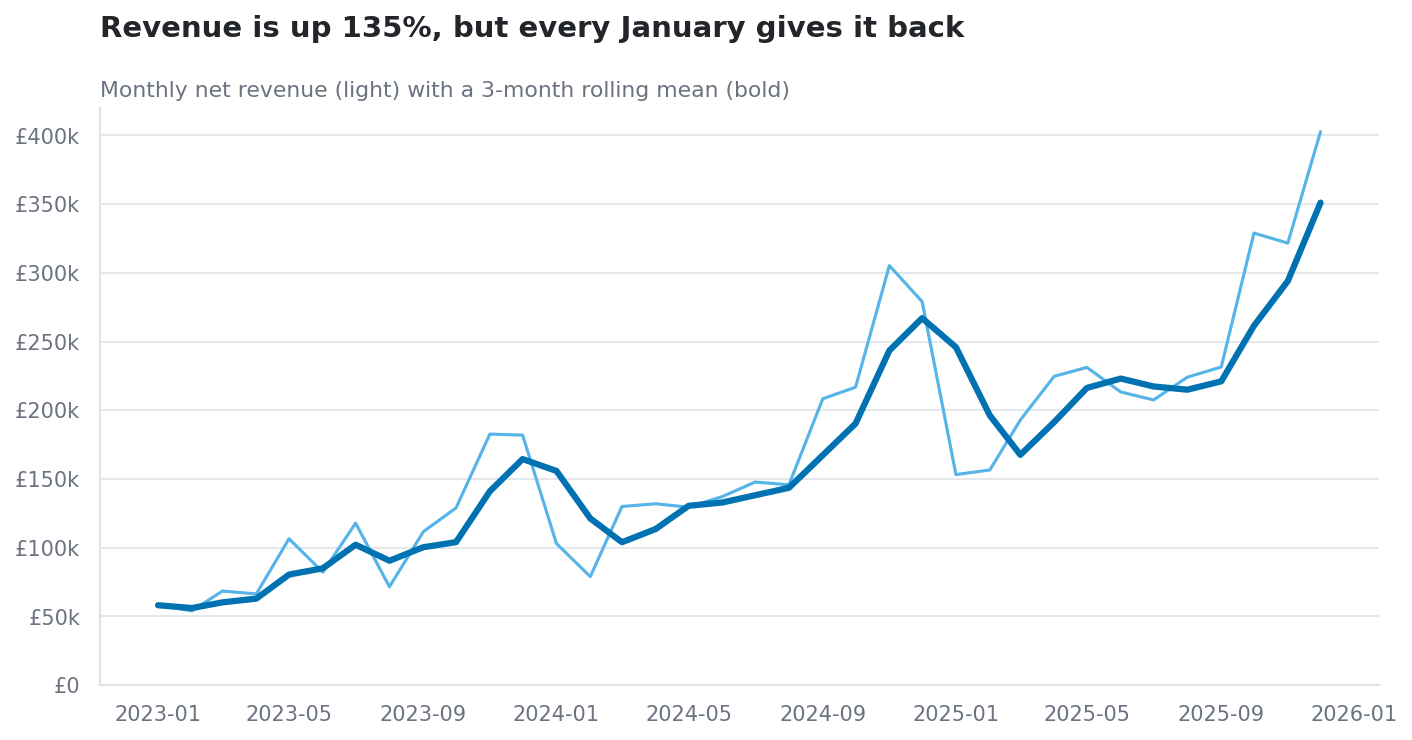

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["order_month"], monthly["net_revenue"], color=ps.OKABE_ITO[4], lw=1.5)
ax.plot(monthly["order_month"], monthly["revenue_3m_avg"], color=ps.ACCENT, lw=3)
ps.titles(ax, f"Revenue is up {growth['growth_first_to_last']:.0%}, but every January gives it back",
          "Monthly net revenue (light) with a 3-month rolling mean (bold)")
ax.set_ylim(bottom=0)
ps.money_axis(ax); ps.style_axes(ax)
plt.show()

The trend is genuinely upward, but the ripples are enormous. Before reading anything into
month-on-month movement we need to know how much of it is just the calendar.

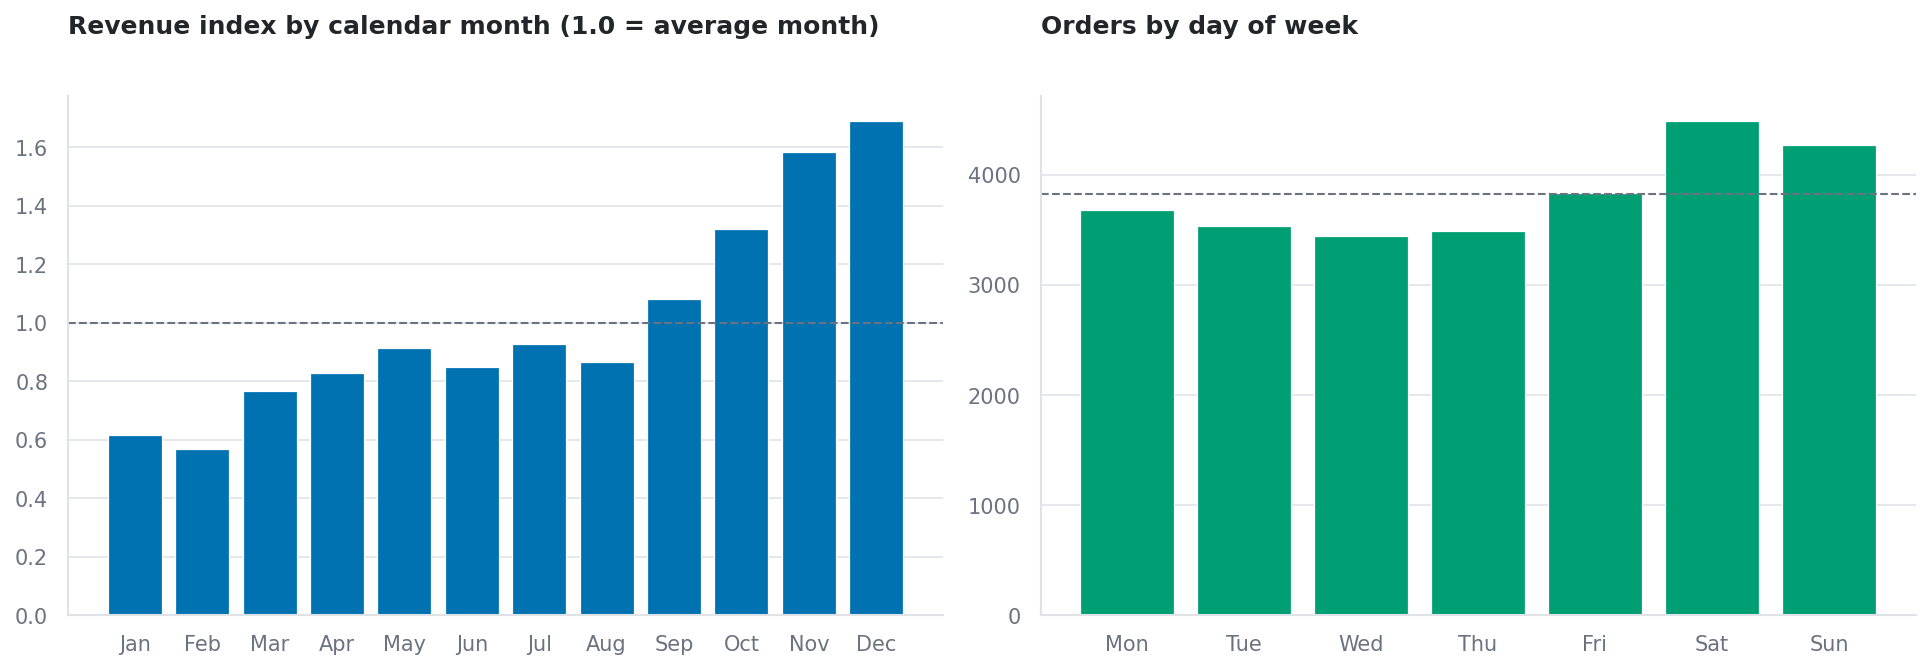

Dec runs at 1.69x an average month.
Weekend share of orders: 33% of orders on 29% of days.


In [12]:
by_month = res["seasonality"]["by_month"]
dow = res["seasonality"]["by_dow"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].bar(by_month["month_name"], by_month["index_vs_avg"], color=ps.ACCENT)
axes[0].axhline(1.0, color=ps.MUTED, ls="--", lw=1)
axes[0].set_title("Revenue index by calendar month (1.0 = average month)", loc="left", fontsize=12)
ps.style_axes(axes[0])

axes[1].bar(dow["day_name"].str[:3], dow["orders"], color=ps.OKABE_ITO[2])
axes[1].axhline(dow["orders"].mean(), color=ps.MUTED, ls="--", lw=1)
axes[1].set_title("Orders by day of week", loc="left", fontsize=12)
ps.style_axes(axes[1])
plt.tight_layout(); plt.show()

peak = by_month.loc[by_month["index_vs_avg"].idxmax()]
print(f"{peak['month_name']} runs at {peak['index_vs_avg']:.2f}x an average month.")
print(f"Weekend share of orders: "
      f"{dow.loc[dow['day_name'].isin(['Saturday','Sunday']), 'orders'].sum() / dow['orders'].sum():.0%} "
      f"of orders on 29% of days.")

**Read:** November and December carry the year; January and February are the trough. Weekends
take a disproportionate share of *orders* but not of *basket value* - so the weekend lift is
traffic, not intent. Any "growth" claim made on a January-to-December comparison is meaningless.

## 5. Where does the money come from?

### 5.1 Product concentration

In [13]:
prod, par = res["products"], res["pareto"]

print(f"{par['n_products_for_80pct']} of {par['n_products']} SKUs "
      f"({par['pct_products_for_80pct']:.0%}) generate 80% of revenue.")
print(f"Top 20% of the range  : {par['top20pct_revenue_share']:.0%} of revenue")
print(f"Bottom half of range  : {par['bottom50pct_revenue_share']:.1%} of revenue")

prod.head(8)[["product_id", "name", "category", "net_revenue", "margin_pct", "cum_revenue_share"]]

89 of 400 SKUs (22%) generate 80% of revenue.
Top 20% of the range  : 78% of revenue
Bottom half of range  : 6.5% of revenue


,product_id,name,category,net_revenue,margin_pct,cum_revenue_share
0,P0218,Pro Phone Pack,Electronics,"565,884.74",0.23,0.09
1,P0290,Signature Phone Kit,Electronics,"393,546.29",0.33,0.16
2,P0079,Everyday Fitnes Collection,Sports & Outdoors,"256,681.25",0.34,0.20
3,P0140,Everyday Audio Collection,Electronics,"245,679.78",0.28,0.24
4,P0148,Signature Cycling Model,Sports & Outdoors,"149,237.56",0.38,0.26
5,P0069,Urban Phone Series,Electronics,"134,219.22",0.14,0.28
6,P0352,Signature Bedding Pack,Home & Kitchen,"128,703.80",0.34,0.31
7,P0173,Deluxe Small Appliance Kit,Home & Kitchen,"126,973.58",0.44,0.33


### 5.2 Category economics: revenue is not profit

,category,net_revenue,revenue_share,gross_profit,profit_share,margin_pct,avg_discount
0,Electronics,"2,597,283.96",0.42,"586,041.25",0.30,0.23,0.07
1,Home & Kitchen,"1,016,451.32",0.17,"392,671.65",0.20,0.39,0.07
2,Sports & Outdoors,"883,361.04",0.14,"277,924.28",0.14,0.31,0.08
3,Apparel,"745,205.35",0.12,"361,570.38",0.19,0.49,0.07
4,Beauty,"323,921.88",0.05,"173,974.77",0.09,0.54,0.07
5,Office Supplies,"296,600.00",0.05,"83,559.26",0.04,0.28,0.07
6,Grocery,"187,497.02",0.03,"42,753.05",0.02,0.23,0.07
7,Toys & Games,"82,971.03",0.01,"31,917.14",0.02,0.38,0.08


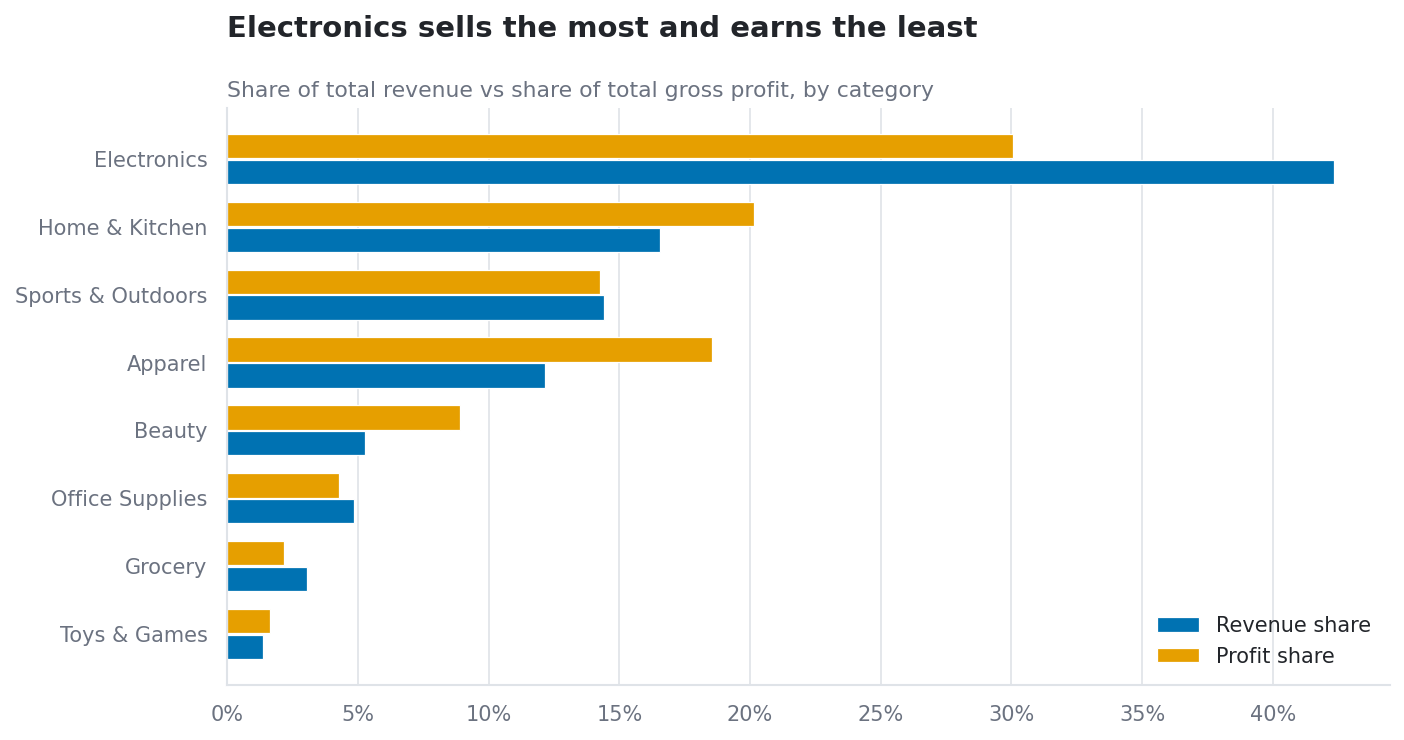

In [14]:
cat = res["categories"]
display(cat[["category", "net_revenue", "revenue_share", "gross_profit",
             "profit_share", "margin_pct", "avg_discount"]])

fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(cat))
ax.barh(idx + 0.19, cat["revenue_share"], height=0.36, color=ps.ACCENT, label="Revenue share")
ax.barh(idx - 0.19, cat["profit_share"], height=0.36, color=ps.ACCENT_2, label="Profit share")
ax.set_yticks(idx, cat["category"])
ax.invert_yaxis()
ps.titles(ax, f"{cat.iloc[0]['category']} sells the most and earns the least",
          "Share of total revenue vs share of total gross profit, by category")
ps.pct_axis(ax, axis="x"); ps.style_axes(ax, xgrid=True, ygrid=False)
ax.legend(loc="lower right")
plt.show()

The gap between the two bars is the whole story: the largest category converts a much smaller
slice of turnover into profit than its size implies. That is a *mix* problem, and mix is
something merchandising can actually move.

## 6. Do customers come back?

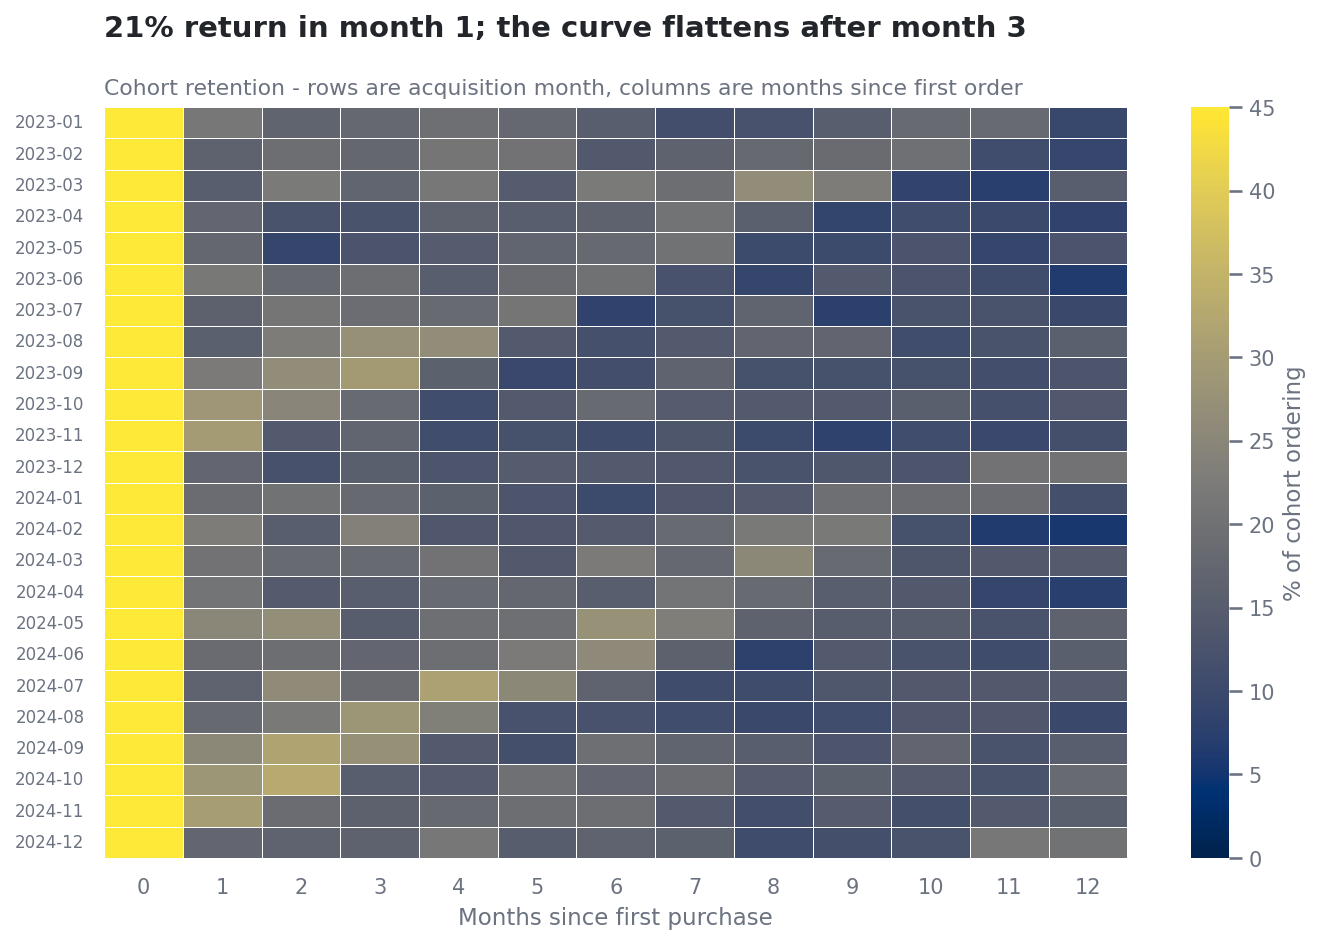

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
retention,1.00,0.21,0.20,0.19,0.18,0.16,0.17,0.16,0.15,0.14,0.14,0.13,0.13


In [15]:
co = res["cohorts"]
matrix = co["matrix"]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap((matrix * 100).iloc[:24], cmap=ps.SEQ_CMAP, annot=False, linewidths=0.4,
            linecolor="white", vmin=0, vmax=45, ax=ax,
            cbar_kws={"label": "% of cohort ordering"})
ax.set_yticks(np.arange(len(matrix.iloc[:24])) + 0.5,
              [d.strftime("%Y-%m") for d in matrix.index[:24]], fontsize=8)
ps.titles(ax, f"{co['m1_retention']:.0%} return in month 1; the curve flattens after month 3",
          "Cohort retention - rows are acquisition month, columns are months since first order")
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("")
plt.show()

co["avg_curve"].round(3).to_frame("retention").T

**Read:** the steep part of the curve is over by month 3. Customers who make it through the
first quarter behave very differently from those who do not - which is exactly what makes an
RFM cut worthwhile.

## 7. Who are the customers worth?

In [16]:
rfm, clv, churn = res["rfm"], res["clv"], res["churn"]
display(rfm[["rfm_segment", "customers", "customer_share", "revenue_share",
             "avg_order_value", "avg_frequency", "avg_recency_days", "avg_clv"]])

champs = rfm[rfm["rfm_segment"] == "Champions"].iloc[0]
print(f"Champions: {champs['customer_share']:.0%} of customers -> {champs['revenue_share']:.0%} of revenue")
print(f"Top revenue decile      : {clv['top_decile_revenue_share']:.0%} of revenue")
print(f"Mean CLV {ps.money(clv['mean_clv'])} vs median {ps.money(clv['median_clv'])} "
      f"- a {clv['mean_clv'] / clv['median_clv']:.1f}x gap, i.e. heavily skewed")

,rfm_segment,customers,customer_share,revenue_share,avg_order_value,avg_frequency,avg_recency_days,avg_clv
0,Champions,1493,0.22,0.46,269.80,7.59,31.35,"2,273.96"
1,Loyal Customers,1075,0.16,0.21,269.86,5.07,108.79,"1,286.29"
2,At Risk,684,0.10,0.14,291.93,4.89,290.26,869.24
3,Can't Lose Them,292,0.04,0.07,354.17,4.43,570.54,807.95
4,Hibernating,1558,0.23,0.05,153.47,1.57,511.36,183.31
5,New / Promising,938,0.14,0.03,138.03,1.73,34.01,726.51
6,Needs Attention,147,0.02,0.02,477.33,2.78,583.69,572.17
7,Potential Loyalist,516,0.08,0.02,143.36,1.68,133.18,473.53


Champions: 22% of customers -> 46% of revenue
Top revenue decile      : 41% of revenue
Mean CLV £1.0k vs median £474 - a 2.2x gap, i.e. heavily skewed


In [17]:
print(f"Customers flagged at churn risk : {churn['n_at_risk']:,} ({churn['at_risk_rate']:.1%})")
print(f"Historic revenue behind them    : {ps.money(churn['revenue_at_risk'])} "
      f"({churn['revenue_at_risk_share']:.0%} of all revenue)")
print(f"High-value (M >= 4) and lapsing : {churn['high_value_at_risk']:,} customers, "
      f"{ps.money(churn['high_value_at_risk_revenue'])}")
churn["by_segment"]

Customers flagged at churn risk : 2,453 (36.6%)
Historic revenue behind them    : £1.68M (27% of all revenue)
High-value (M >= 4) and lapsing : 738 customers, £1.27M


,rfm_segment,customers,at_risk,revenue_at_risk,at_risk_rate
0,Hibernating,1558,1311,"267,940.87",0.84
1,At Risk,684,431,"595,935.58",0.63
2,Can't Lose Them,292,281,"396,538.07",0.96
3,Loyal Customers,1075,197,"291,909.13",0.18
4,Needs Attention,147,132,"108,512.22",0.90
5,Potential Loyalist,516,101,"21,849.66",0.20
6,Champions,1493,0,0.00,0.00
7,New / Promising,938,0,0.00,0.00


## 8. Testing the differences instead of eyeballing them

Three questions worth a formal test. In each case the assumptions are checked, an effect size
is reported next to the p-value, and a distribution-free fallback is run so the conclusion does
not rest on a normality assumption that order values obviously violate.

In [18]:
for t in res["tests"]:
    print("=" * 100)
    print(t["name"])
    print("=" * 100)
    print(t["interpretation"])
    print()

S1. AOV: Web vs Mobile App (Welch two-sample t-test)
Web orders average 266.72 and Mobile App orders 172.57, a difference of 94.16 (+54.6% vs mobile). Welch's t-test gives t = 9.99, p < 0.0001, which is below the 0.05 threshold, so the gap is very unlikely to be a fluke of sampling - it is a real, persistent difference in basket value between the two channels. The standardised effect size is negligible (Cohen's d = 0.14) because order values are enormously dispersed within each channel - but the commercial gap is not small: 94 on every mobile order, or roughly 260,560 a year at current mobile volumes. Levene's test on variances is p < 0.0001 (variances differ, which is exactly why Welch's version was used). The non-parametric Mann-Whitney U agrees (p < 0.0001), so the conclusion does not depend on the normality assumption.

S2. Customer segment x region (chi-square test of independence)
Chi-square = 70.3 on 12 degrees of freedom, p < 0.0001. Because p < 0.0001 is below 0.05, segment an

A note on interpretation: with ~27,000 orders almost any difference will be "significant".
That is why every test above also reports an effect size (Cohen's *d*, Cramer's *V*,
eta-squared). The channel AOV gap is commercially large but statistically *small* in
standardised terms, because order values are enormously dispersed - both facts are true, and
only reporting the p-value would mislead.

## 9. The published figures

The full set of fourteen charts is written to `reports/figures/` by `src/visualize.py`. Two of
them, for reference:

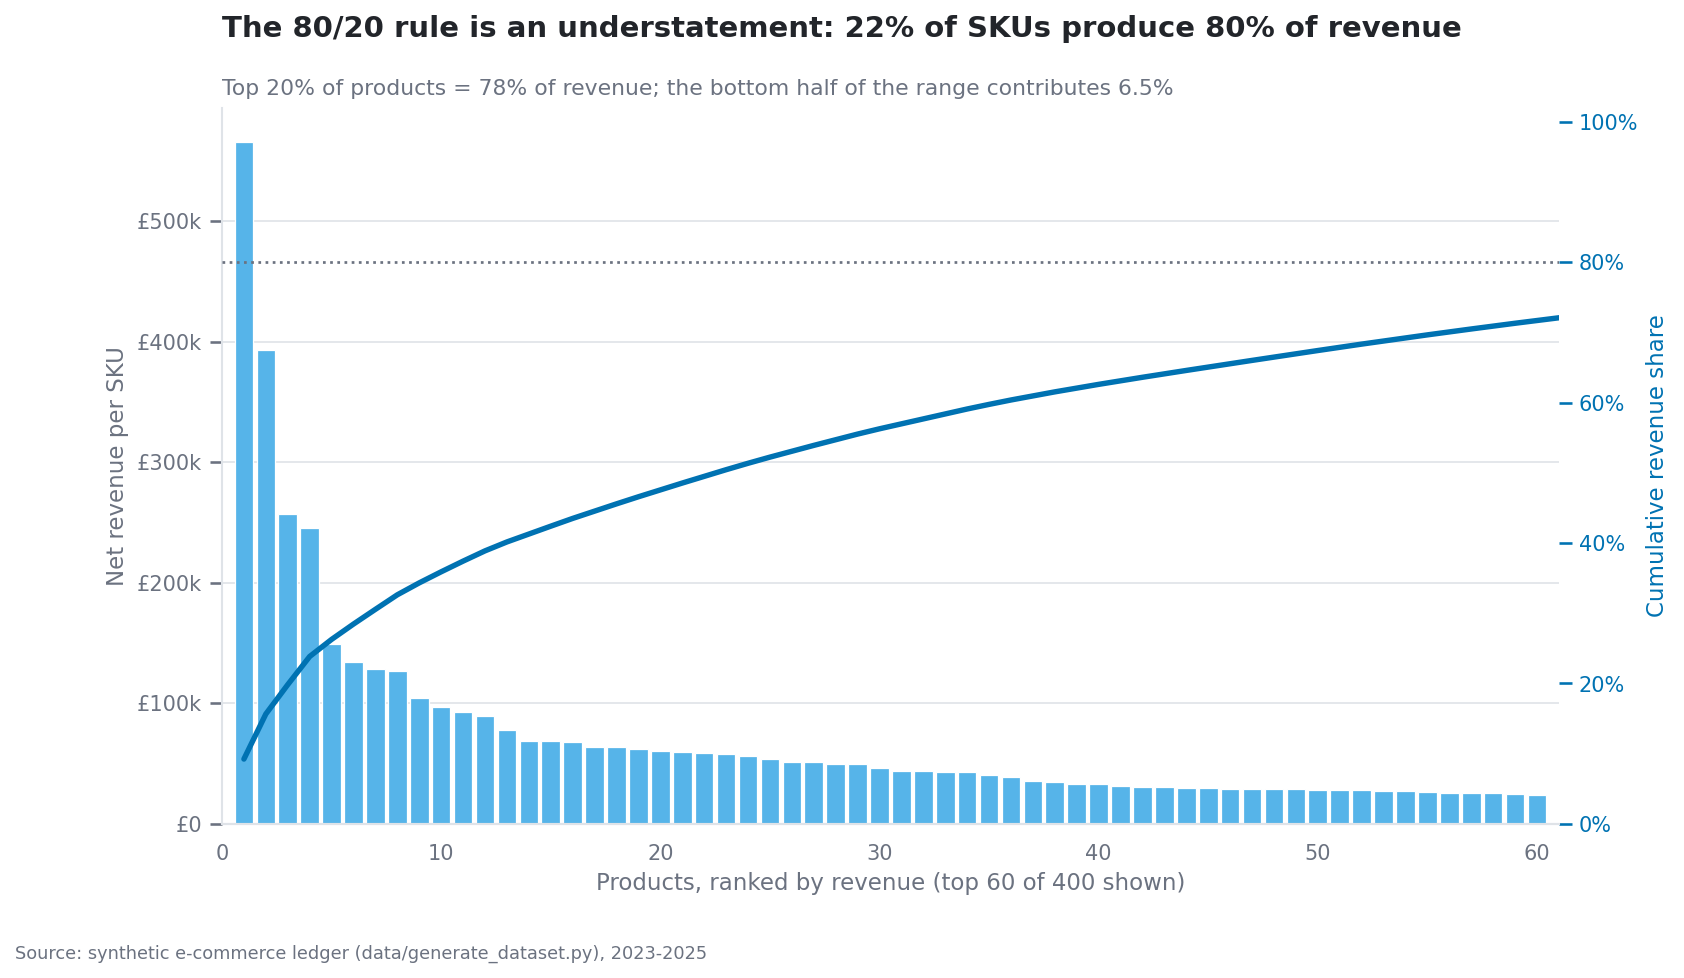

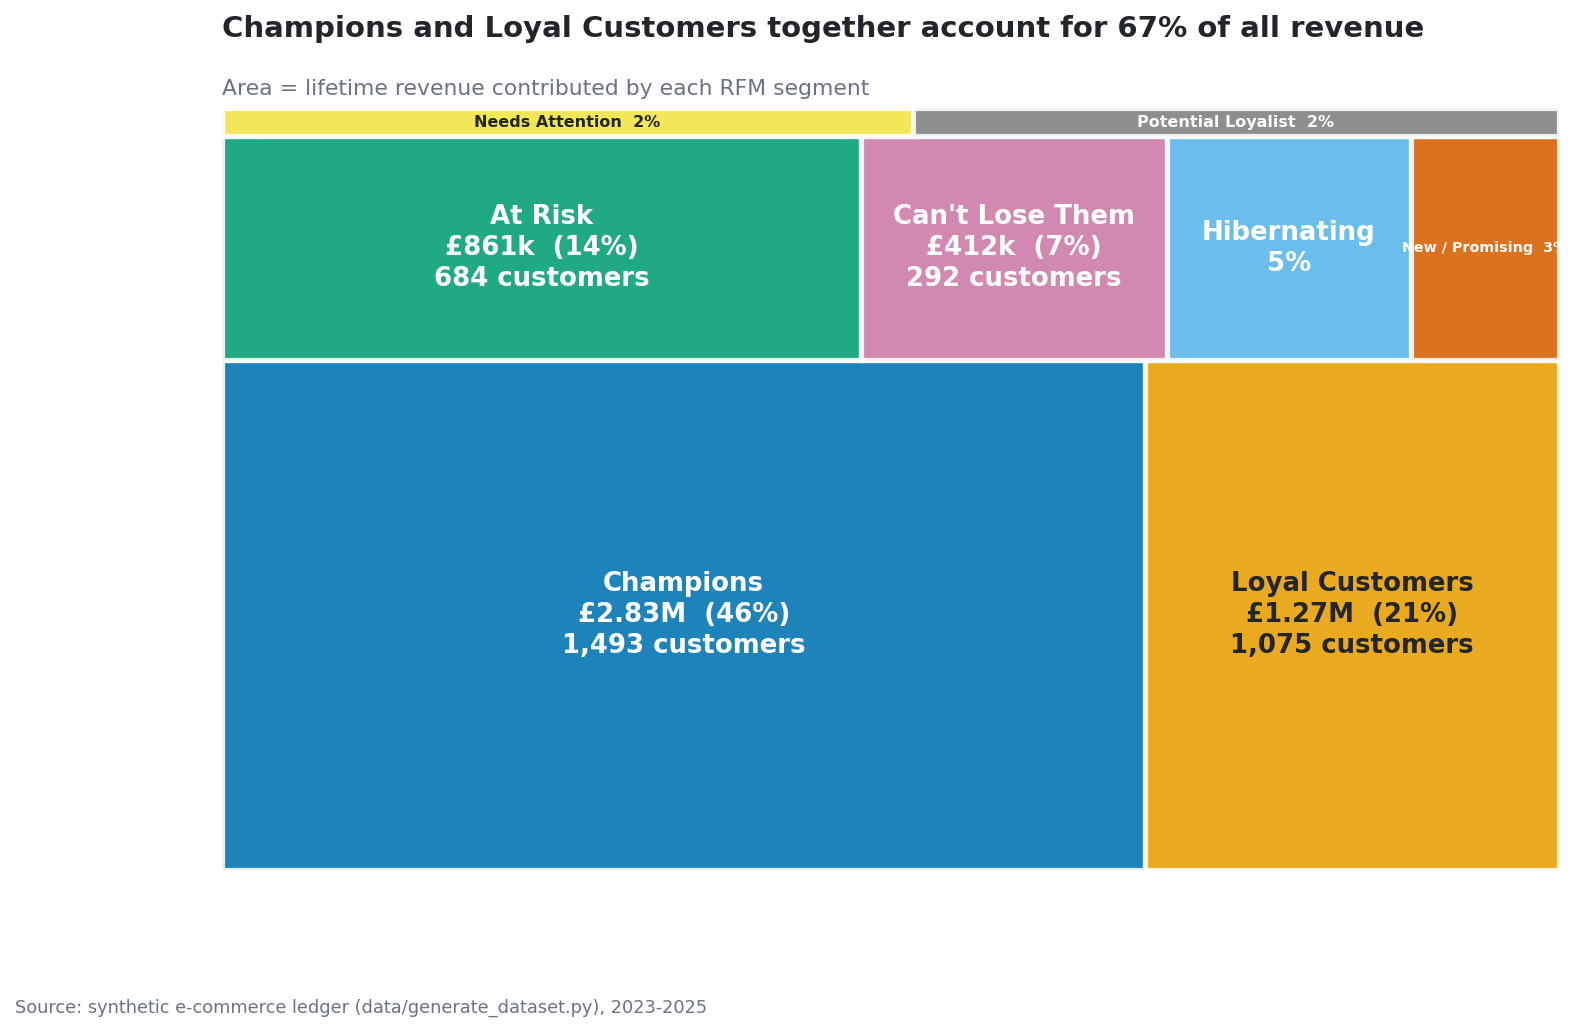

In [19]:
from IPython.display import Image, display

for name in ["05_product_pareto.png", "12_rfm_treemap.png"]:
    path = os.path.join("..", "reports", "figures", name)
    if os.path.exists(path):
        display(Image(filename=path, width=900))

## 10. What this analysis says

1. Growth is real over the period, but **seasonal**: November-December carry the year, and January hands a large slice of it straight back.
2. The range is far more concentrated than 80/20 - a small core of SKUs does the work.
3. The largest category is the thinnest-margin one; mix, not volume, is the profit lever.
4. A fifth of customers ("Champions") produce close to half of revenue.
5. Retention decays hard in the first quarter, and a large share of the base is already lapsing.

The full write-up, with every table and all fourteen figures, is in
[`reports/findings.md`](../reports/findings.md); data-quality provenance is in
[`reports/data_quality_report.md`](../reports/data_quality_report.md).